# Pm2.5 Modelling

## Phase 1

In [12]:
import pandas as pd

# Load the CSV sample file
file_path = 'LAEI-2019-Emissions-Summary-including-Forecast/2019filteredatacsv.csv'
df = pd.read_csv(file_path)

# Step 1: View dataset structure
print("=== Data Overview ===")
print(df.info())
print(df.head())

# Step 2: Check for missing values
print("\n=== Missing Values ===")
print(df.isnull().sum())

# Step 3: Unique values for categorical inspection
print("\n=== Unique Values per Column ===")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

# Step 4: Basic statistics
print("\n=== Descriptive Statistics ===")
print(df.describe(include='all'))

=== Data Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143976 entries, 0 to 143975
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Year                  143976 non-null  int64  
 1   Grid ID 2019          143976 non-null  int64  
 2   LAEI 1km2 ID          143976 non-null  int64  
 3   Easting               143976 non-null  int64  
 4   Northing              143976 non-null  int64  
 5   Borough               143976 non-null  object 
 6   Zone                  143976 non-null  object 
 7   Main Source Category  143976 non-null  object 
 8   Sector                143976 non-null  object 
 9   Source                143976 non-null  object 
 10  bap                   31140 non-null   float64
 11  cd                    17300 non-null   float64
 12  c4h6                  34600 non-null   float64
 13  c6h6                  44980 non-null   float64
 14  ch4                   51900 no

In [13]:
import pandas as pd

# Reload the full dataset for cleaning
file_path = 'LAEI-2019-Emissions-Summary-including-Forecast/2019filteredatacsv.csv'
df = pd.read_csv(file_path)

# Step 1: Drop unnecessary or low-value columns
drop_columns = [
    'Year', 'Grid ID 2019', 'LAEI 1km2 ID', 'Easting', 'Northing',
    'bap', 'cd', 'c4h6', 'c6h6', 'ch4', 'co', 'hc', 'hcl', 'hg', 'n2o',
    'nh3', 'nmvoc', 'pb', 'pcb', 'so2', 'Emissions Unit'
]
df.drop(columns=drop_columns, inplace=True)

# Step 2: Label encode categorical features
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Borough', 'Zone', 'Main Source Category', 'Sector', 'Source']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le  # Save for inverse transformation later

print("Data cleaned and encoded.")
print(df.head())

# Step 3: Show the cleaned and encoded DataFrame
df.to_csv("LAEI2019_Cleaned.csv", index=False)
print("Cleaned data saved to 'LAEI2019_Cleaned.csv'")

Data cleaned and encoded.
   Borough  Zone  Main Source Category  Sector  Source          co2       nox  \
0        6     0                     4      14      36   801.702422  0.815941   
1       19     0                     4      14      36    96.064233  0.146172   
2        5     0                     4      14      36  1654.324756  1.342779   
3       29     0                     4      14      36  1307.588067  0.933334   
4       29     1                     4      14      36   268.764076  0.225646   

       pm10     pm2.5  
0  0.202529  0.090511  
1  0.030548  0.013716  
2  0.398525  0.177336  
3  0.309936  0.137778  
4  0.050658  0.022702  
Cleaned data saved to 'LAEI2019_Cleaned.csv'


## Phase 2

In [14]:
# Load cleaned dataset
df = pd.read_csv("LAEI2019_Cleaned.csv")

# Preview missing data in NOx and CO2
print("Missing NOx:", df['nox'].isnull().sum())
print("Missing CO2:", df['co2'].isnull().sum())

# Quick preview of data structure
print(df.info())
df.head()

Missing NOx: 20760
Missing CO2: 31140
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143976 entries, 0 to 143975
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Borough               143976 non-null  int64  
 1   Zone                  143976 non-null  int64  
 2   Main Source Category  143976 non-null  int64  
 3   Sector                143976 non-null  int64  
 4   Source                143976 non-null  int64  
 5   co2                   112836 non-null  float64
 6   nox                   123216 non-null  float64
 7   pm10                  140516 non-null  float64
 8   pm2.5                 140516 non-null  float64
dtypes: float64(4), int64(5)
memory usage: 9.9 MB
None


,Borough,Zone,Main Source Category,Sector,Source,co2,nox,pm10,pm2.5
0,6,0,4,14,36,801.702422,0.815941,0.202529,0.090511
1,19,0,4,14,36,96.064233,0.146172,0.030548,0.013716
2,5,0,4,14,36,1654.324756,1.342779,0.398525,0.177336
3,29,0,4,14,36,1307.588067,0.933334,0.309936,0.137778
4,29,1,4,14,36,268.764076,0.225646,0.050658,0.022702


In [15]:
from sklearn.ensemble import RandomForestRegressor

# Load cleaned dataset
df = pd.read_csv("LAEI2019_Cleaned.csv")

# Step 2.1: Define features and target for NOx
features = ['co2', 'pm10', 'pm2.5', 'Borough', 'Zone', 'Main Source Category', 'Sector', 'Source']
target = 'nox'

# Step 2.2: Split into rows with known and missing NOx
nox_known = df[df['nox'].notnull()]
nox_missing = df[df['nox'].isnull()]

# Step 2.3: Prepare training data
X_train_nox = nox_known[features]
y_train_nox = nox_known[target]

# Step 2.4: Prepare prediction data
X_pred_nox = nox_missing[features]

# Step 3.1: Train the Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

nox_model = RandomForestRegressor(n_estimators=100, random_state=42)
nox_model.fit(X_train_nox, y_train_nox)

# Step 3.2: Predict missing NOx values
nox_predictions = nox_model.predict(X_pred_nox)

# Step 3.3: Fill in the predicted values
df.loc[df['nox'].isnull(), 'nox'] = nox_predictions

print(" Missing NOx values imputed:", len(nox_predictions))
# Step 1: Define features and target for CO2
features_co2 = ['nox', 'pm10', 'pm2.5', 'Borough', 'Zone', 'Main Source Category', 'Sector', 'Source']
target_co2 = 'co2'

# Step 2: Split into known and missing
co2_known = df[df['co2'].notnull()]
co2_missing = df[df['co2'].isnull()]

# Step 3: Prepare training data
X_train_co2 = co2_known[features_co2]
y_train_co2 = co2_known[target_co2]

# Step 4: Drop rows where predictors are still missing
X_pred_co2 = co2_missing[features_co2].dropna()
rows_to_fill = X_pred_co2.index  # store the index to match back

# Train and predict
co2_model = RandomForestRegressor(n_estimators=100, random_state=42)
co2_model.fit(X_train_co2, y_train_co2)
co2_predictions = co2_model.predict(X_pred_co2)

# Fill only the rows we could predict
df.loc[rows_to_fill, 'co2'] = co2_predictions

print("Imputed CO2 values:", len(co2_predictions))
df.to_csv("LAEI2019_Final_Imputed.csv", index=False)

 Missing NOx values imputed: 20760
Imputed CO2 values: 27680


## Model Training

In [16]:
# PM2.5 Prediction – Model Setup and Cleaning
from sklearn.model_selection import train_test_split

# Load the final cleaned and imputed dataset
df = pd.read_csv("LAEI2019_Final_Imputed.csv")

# Define target and feature set
y_pm25 = df['pm2.5']
X_pm25 = df.drop(columns=['pm2.5'])

# Drop rows with missing data
combined_pm25 = pd.concat([X_pm25, y_pm25], axis=1).dropna()

X_pm25_clean = combined_pm25.drop(columns=['pm2.5'])
y_pm25_clean = combined_pm25['pm2.5']

# Train/test split
X_train_pm25, X_test_pm25, y_train_pm25, y_test_pm25 = train_test_split(
    X_pm25_clean, y_pm25_clean, test_size=0.2, random_state=42
)

# Step 4: Linear Regression for PM2.5 Prediction
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train the model
lr_pm25 = LinearRegression()
lr_pm25.fit(X_train_pm25, y_train_pm25)

# Predict
y_pred_lr_pm25 = lr_pm25.predict(X_test_pm25)

# Evaluate
mae_lr_pm25 = mean_absolute_error(y_test_pm25, y_pred_lr_pm25)
rmse_lr_pm25 = np.sqrt(mean_squared_error(y_test_pm25, y_pred_lr_pm25))
r2_lr_pm25 = r2_score(y_test_pm25, y_pred_lr_pm25)

# Print results
print("Linear Regression Results – PM2.5:")
print(f"R² Score: {r2_lr_pm25:.4f}")
print(f"MAE: {mae_lr_pm25:.4f}")
print(f"RMSE: {rmse_lr_pm25:.4f}")

Linear Regression Results – PM2.5:
R² Score: 0.4645
MAE: 0.0244
RMSE: 0.1171


In [17]:
# PM2.5 Prediction Using Random Forest Regressor

# Train the Random Forest model
rf_pm25 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_pm25.fit(X_train_pm25, y_train_pm25)

# Predict
y_pred_rf_pm25 = rf_pm25.predict(X_test_pm25)

# Evaluate
mae_rf_pm25 = mean_absolute_error(y_test_pm25, y_pred_rf_pm25)
rmse_rf_pm25 = np.sqrt(mean_squared_error(y_test_pm25, y_pred_rf_pm25))
r2_rf_pm25 = r2_score(y_test_pm25, y_pred_rf_pm25)

# Print results
print("Random Forest Regression Results – PM2.5:")
print(f"R² Score: {r2_rf_pm25:.4f}")
print(f"MAE: {mae_rf_pm25:.4f}")
print(f"RMSE: {rmse_rf_pm25:.4f}")

Random Forest Regression Results – PM2.5:
R² Score: 0.9075
MAE: 0.0011
RMSE: 0.0487


In [18]:
# PM2.5 Prediction Using XGBoost Regressor
from xgboost import XGBRegressor

# Train the XGBoost model
xgb_pm25 = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_pm25.fit(X_train_pm25, y_train_pm25)

# Predict
y_pred_xgb_pm25 = xgb_pm25.predict(X_test_pm25)

# Evaluate
mae_xgb_pm25 = mean_absolute_error(y_test_pm25, y_pred_xgb_pm25)
rmse_xgb_pm25 = np.sqrt(mean_squared_error(y_test_pm25, y_pred_xgb_pm25))
r2_xgb_pm25 = r2_score(y_test_pm25, y_pred_xgb_pm25)

# Print results
print("XGBoost Regression Results – PM2.5:")
print(f"R² Score: {r2_xgb_pm25:.4f}")
print(f"MAE: {mae_xgb_pm25:.4f}")
print(f"RMSE: {rmse_xgb_pm25:.4f}")

XGBoost Regression Results – PM2.5:
R² Score: 0.4410
MAE: 0.0038
RMSE: 0.1197


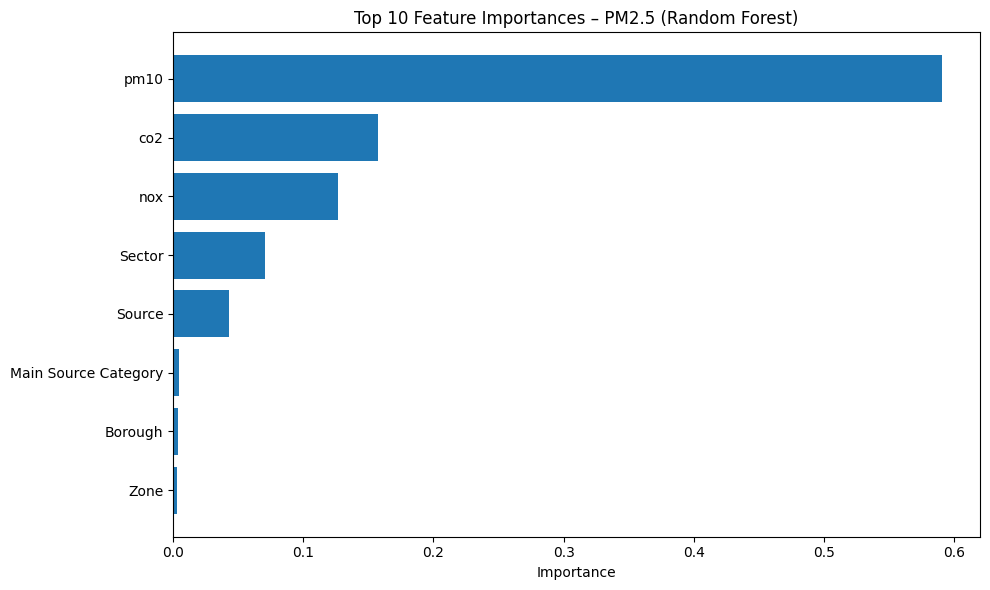

                Feature  Importance
7                  pm10    0.590349
5                   co2    0.157600
6                   nox    0.126317
3                Sector    0.070982
4                Source    0.043220
2  Main Source Category    0.004658
0               Borough    0.003522
1                  Zone    0.003353


In [19]:
# Feature Importance – PM2.5 (Random Forest)
import matplotlib.pyplot as plt

# Get feature importances from the trained model
importances_pm25 = rf_pm25.feature_importances_
feature_names_pm25 = X_train_pm25.columns

# Create a DataFrame and sort
importance_df_pm25 = pd.DataFrame({
    'Feature': feature_names_pm25,
    'Importance': importances_pm25
}).sort_values(by='Importance', ascending=False)

# Plot top 10 features
plt.figure(figsize=(10, 6))
plt.barh(importance_df_pm25['Feature'][:10], importance_df_pm25['Importance'][:10])
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances – PM2.5 (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


# Display the full sorted table
print(importance_df_pm25)